# 📊 **APE 008 – Distribuciones Muestrales y Teorema del Límite Central**
## Simulación Estocástica aplicada al Dataset Regional de Loja

**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja
- Link del municipio de Loja: https://www.loja.gob.ec/contenido/2023-lotaip
- Enlace dataset (Google Drive): https://docs.google.com/spreadsheets/d/1ERWZnpgxC-Ffaj-sxMB5El0sgge_QX4g/edit?usp=drive_link

**Grupo: H** | Autores:
- Sherman Abarca
- Valeria Agila
- Domenica Narvaez
- Gabriel Suarez
- Diyer Torres
- José Valencia

**Objetivo:** Demostrar computacionalmente el Teorema del Límite Central (TLC),
aplicar técnicas de remuestreo sobre el dataset regional e investigar el impacto
del tamaño muestral en el Error Estándar de la Media.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew

# Estilo visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("✅ Todas las librerías importadas correctamente.")

✅ Todas las librerías importadas correctamente.


---
## 📐 **Tarea 1** — Generación de una Población Asimétrica (No Normal)

El **Teorema del Límite Central (TLC)** establece que, dada una población
con media $\mu$ y varianza finita $\sigma^2$, la distribución de las medias
muestrales $\bar{X}$ se aproximará a una distribución Normal $N(\mu, \sigma^2/n)$
a medida que el tamaño de la muestra $n$ aumenta.

Para demostrar esto, primero necesitamos una población que **claramente NO sea normal**.
Simularemos el tiempo de permanencia de usuarios en un portal web usando una
distribución **Exponencial** con $\lambda = 0.5$ (media poblacional $= 2.0$).

TAREA 1: Generación de una Población Asimétrica (No Normal)
--- Parámetros Poblacionales Reales ---
Media (μ)              : 1.9919
Desviación Estándar (σ): 1.9859
Asimetría (skewness)   : 1.9921  ← muy alejada de 0 (Normal)


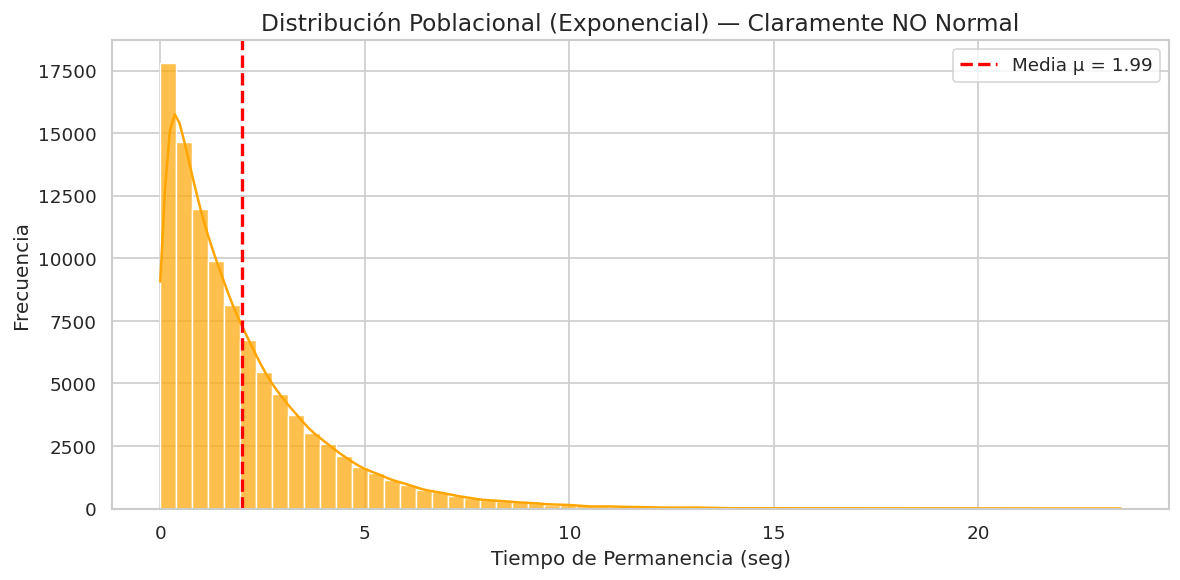

In [ ]:
print("=====================================================================")
print("TAREA 1: Generación de una Población Asimétrica (No Normal)")
print("=====================================================================")

# 1. Creación de la Población "Universo" (Altamente asimétrica)
np.random.seed(42)
poblacion_exponencial = np.random.exponential(scale=2.0, size=100_000)

mu_pob  = np.mean(poblacion_exponencial)
sigma_pob = np.std(poblacion_exponencial)

print(f"--- Parámetros Poblacionales Reales ---")
print(f"Media (μ)              : {mu_pob:.4f}")
print(f"Desviación Estándar (σ): {sigma_pob:.4f}")
print(f"Asimetría (skewness)   : {skew(poblacion_exponencial):.4f}  ← muy alejada de 0 (Normal)")

# Visualización de la Población Original
plt.figure(figsize=(10, 5))
sns.histplot(poblacion_exponencial, bins=60, kde=True, color='orange', alpha=0.7)
plt.title("Distribución Poblacional (Exponencial) — Claramente NO Normal")
plt.xlabel("Tiempo de Permanencia (seg)")
plt.ylabel("Frecuencia")
plt.axvline(mu_pob, color='red', linestyle='dashed', linewidth=2,
            label=f'Media μ = {mu_pob:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🔁 **Tarea 2** — Simulación Estocástica del Teorema del Límite Central

Extraeremos **1000 muestras aleatorias** de tamaño $n = 30$ de la población
exponencial. Para cada muestra calcularemos su media $\bar{x}$, y luego
graficaremos la distribución de esas 1000 medias.

Según el TLC, aunque la población original sea asimétrica, la distribución
de las medias muestrales debería converger a una **campana Normal**.

TAREA 2: Simulación del Teorema del Límite Central (Monte Carlo)

--- Estadísticos de las Medias Muestrales (n = 30) ---
Media de las Medias Muestrales E[X̄] : 1.9923
Media Poblacional μ                  : 1.9919
Diferencia |E[X̄] - μ|               : 0.0004  ← debe ser ≈ 0

Error Estándar Empírico  (σ_x̄)     : 0.3653
Error Estándar Teórico   (σ/√n)     : 0.3626
Diferencia                           : 0.0027


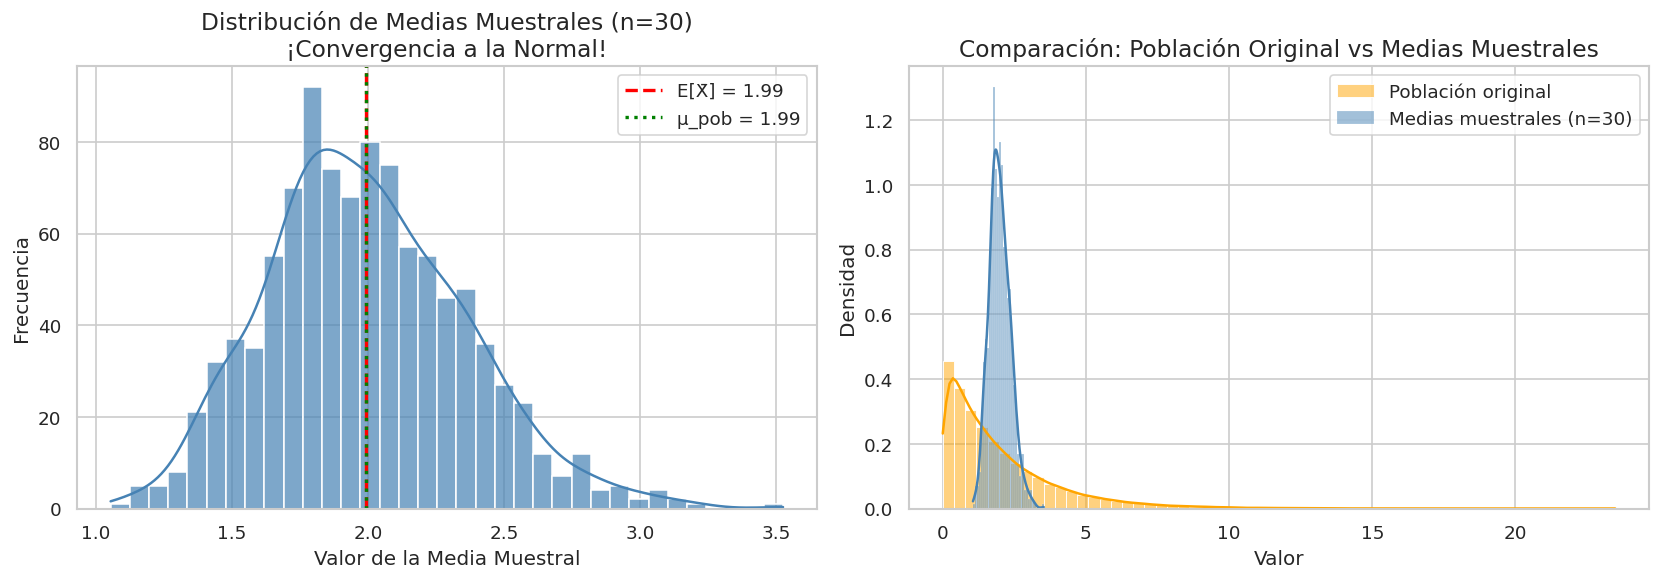

In [ ]:
print("=====================================================================")
print("TAREA 2: Simulación del Teorema del Límite Central (Monte Carlo)")
print("=====================================================================")

# Parámetros de la simulación
tamaño_muestra  = 30    # n
numero_muestras = 1000  # k

# Array para almacenar las medias de cada muestra
medias_muestrales = []

# Bucle de Monte Carlo
for _ in range(numero_muestras):
    muestra = np.random.choice(poblacion_exponencial,
                               size=tamaño_muestra, replace=False)
    medias_muestrales.append(np.mean(muestra))

medias_muestrales = np.array(medias_muestrales)

# Estadísticos de la Distribución Muestral
media_de_medias        = np.mean(medias_muestrales)
error_estandar_emp     = np.std(medias_muestrales)
error_estandar_teo     = sigma_pob / np.sqrt(tamaño_muestra)

print(f"\n--- Estadísticos de las Medias Muestrales (n = {tamaño_muestra}) ---")
print(f"Media de las Medias Muestrales E[X̄] : {media_de_medias:.4f}")
print(f"Media Poblacional μ                  : {mu_pob:.4f}")
print(f"Diferencia |E[X̄] - μ|               : {abs(media_de_medias - mu_pob):.4f}  ← debe ser ≈ 0")
print(f"\nError Estándar Empírico  (σ_x̄)     : {error_estandar_emp:.4f}")
print(f"Error Estándar Teórico   (σ/√n)     : {error_estandar_teo:.4f}")
print(f"Diferencia                           : {abs(error_estandar_emp - error_estandar_teo):.4f}")

# Visualización de la convergencia a la Normal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica izquierda: distribución de medias muestrales
sns.histplot(medias_muestrales, bins=35, kde=True,
             color='steelblue', alpha=0.7, ax=axes[0])
axes[0].axvline(media_de_medias, color='red', linestyle='dashed', linewidth=2,
                label=f'E[X̄] = {media_de_medias:.2f}')
axes[0].axvline(mu_pob, color='green', linestyle='dotted', linewidth=2,
                label=f'μ_pob = {mu_pob:.2f}')
axes[0].set_title(f"Distribución de Medias Muestrales (n={tamaño_muestra})\n¡Convergencia a la Normal!")
axes[0].set_xlabel("Valor de la Media Muestral")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Gráfica derecha: comparación población vs medias
sns.histplot(poblacion_exponencial, bins=60, kde=True,
             color='orange', alpha=0.5, stat='density',
             label='Población original', ax=axes[1])
sns.histplot(medias_muestrales, bins=35, kde=True,
             color='steelblue', alpha=0.5, stat='density',
             label=f'Medias muestrales (n={tamaño_muestra})', ax=axes[1])
axes[1].set_title("Comparación: Población Original vs Medias Muestrales")
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 🌎 **Tarea 3** — Hito del Proyecto: Remuestreo sobre el Dataset Regional (ABP)

Aplicamos el mismo principio del TLC sobre nuestra variable real:
**Remuneración Mensual Unificada** del Municipio de Loja.

En la APE 007 demostramos con Shapiro-Wilk que esta variable **NO es normal**
(W = 0.5988, p = 3.22e-63, asimetría = 3.75). Sin embargo, gracias al TLC,
si extraemos muchas muestras y calculamos sus medias, esas medias sí se
distribuirán aproximadamente de forma normal, lo que permite hacer inferencia
estadística válida sobre la población.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales.xlsx


TAREA 3: Remuestreo (Bootstrapping) sobre Dataset Regional — Loja

--- Parámetros del Dataset Regional ---
Variable analizada     : Remuneración Mensual Unificada
Total registros        : 2883
Media poblacional (μ)  : $713.81
Desviación estándar (σ): $265.10
Asimetría (skewness)   : 3.7527  ← distribución NO normal

--- Resultados del Remuestreo (k=500, n=40) ---
Media de las medias muestrales E[X̄]: $711.09
Error Estándar Empírico             : $39.80
Error Estándar Teórico (σ/√n)       : $41.92


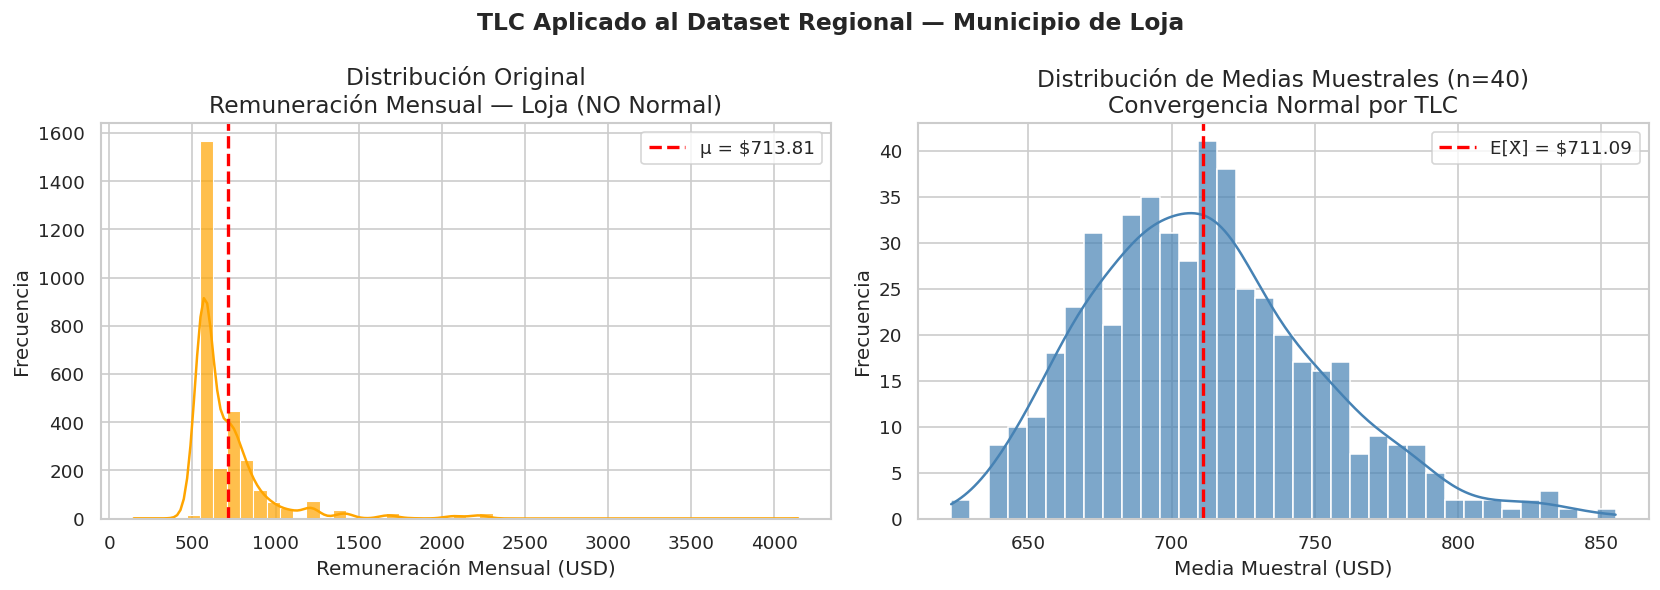

In [ ]:
print("=====================================================================")
print("TAREA 3: Remuestreo (Bootstrapping) sobre Dataset Regional — Loja")
print("=====================================================================")

# Carga y limpieza del dataset
df = pd.read_excel('3._remuneraciones_ingresos_adicionales.xlsx')
datos_loja = pd.to_numeric(
    df['Remuneración mensual unificada'], errors='coerce'
).dropna()

mu_loja    = datos_loja.mean()
sigma_loja = datos_loja.std()

print(f"\n--- Parámetros del Dataset Regional ---")
print(f"Variable analizada     : Remuneración Mensual Unificada")
print(f"Total registros        : {len(datos_loja)}")
print(f"Media poblacional (μ)  : ${mu_loja:.2f}")
print(f"Desviación estándar (σ): ${sigma_loja:.2f}")
print(f"Asimetría (skewness)   : {skew(datos_loja):.4f}  ← distribución NO normal")

# Remuestreo: 500 muestras de tamaño n=40 con reemplazo (bootstrapping)
np.random.seed(42)
n_remuestreo    = 40
k_remuestreo    = 500
medias_loja     = []

for _ in range(k_remuestreo):
    muestra = datos_loja.sample(n=n_remuestreo, replace=True)
    medias_loja.append(muestra.mean())

medias_loja = np.array(medias_loja)

media_de_medias_loja = np.mean(medias_loja)
ee_empirico_loja     = np.std(medias_loja)
ee_teorico_loja      = sigma_loja / np.sqrt(n_remuestreo)

print(f"\n--- Resultados del Remuestreo (k={k_remuestreo}, n={n_remuestreo}) ---")
print(f"Media de las medias muestrales E[X̄]: ${media_de_medias_loja:.2f}")
print(f"Error Estándar Empírico             : ${ee_empirico_loja:.2f}")
print(f"Error Estándar Teórico (σ/√n)       : ${ee_teorico_loja:.2f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: distribución original (asimétrica)
sns.histplot(datos_loja, bins=50, kde=True,
             color='orange', alpha=0.7, ax=axes[0])
axes[0].axvline(mu_loja, color='red', linestyle='dashed', linewidth=2,
                label=f'μ = ${mu_loja:.2f}')
axes[0].set_title("Distribución Original\nRemuneración Mensual — Loja (NO Normal)")
axes[0].set_xlabel("Remuneración Mensual (USD)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Derecha: distribución de medias muestrales (Normal por TLC)
sns.histplot(medias_loja, bins=35, kde=True,
             color='steelblue', alpha=0.7, ax=axes[1])
axes[1].axvline(media_de_medias_loja, color='red', linestyle='dashed', linewidth=2,
                label=f'E[X̄] = ${media_de_medias_loja:.2f}')
axes[1].set_title(f"Distribución de Medias Muestrales (n={n_remuestreo})\nConvergencia Normal por TLC")
axes[1].set_xlabel("Media Muestral (USD)")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.suptitle("TLC Aplicado al Dataset Regional — Municipio de Loja",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📝 **Interpretación de la Tarea 3**

La variable **Remuneración Mensual Unificada** del Municipio de Loja presenta
una asimetría de **3.75**, lo que confirma que **no sigue una distribución normal**.
La mayoría de los 2.883 empleados gana entre $460 y $733, pero un grupo reducido
de directivos con sueldos de hasta $4.144 genera una cola muy larga hacia la derecha.

Sin embargo, al aplicar **bootstrapping** (500 muestras de tamaño n=40), la
distribución de las medias muestrales sí converge a una forma de campana Normal,
con:
- **E[X̄] ≈ $711** — muy cercano a la media poblacional real de $713.81
- **Error Estándar empírico ≈ $39.80** vs. teórico de $41.92 — diferencia mínima

Esto demuestra que el TLC **resuelve el problema de asimetría**: aunque los
datos individuales no son normales, las medias de muestras sí lo son. Esto
permite al Municipio de Loja construir intervalos de confianza y realizar
inferencias estadísticas válidas sobre el salario promedio de sus servidores.

---
## 🔬 **Tarea 4** — ABI: Análisis del Error Estándar y Ley de los Grandes Números

El **Error Estándar de la Media** se define como:

$$SE = \frac{\sigma}{\sqrt{n}}$$

A medida que $n$ aumenta, el Error Estándar **disminuye**, lo que significa
que nuestras estimaciones de la media poblacional se vuelven más precisas.
Investigaremos este comportamiento iterando sobre distintos tamaños de muestra.

TAREA 4: Análisis del Error Estándar — Ley de los Grandes Números
n =    5 | EE Empírico = $121.3386 | EE Teórico = $118.5549
n =   10 | EE Empírico = $89.3776 | EE Teórico = $83.8309
n =   30 | EE Empírico = $49.8535 | EE Teórico = $48.3998
n =   50 | EE Empírico = $37.9279 | EE Teórico = $37.4903
n =  100 | EE Empírico = $27.3127 | EE Teórico = $26.5097
n =  500 | EE Empírico = $12.6096 | EE Teórico = $11.8555


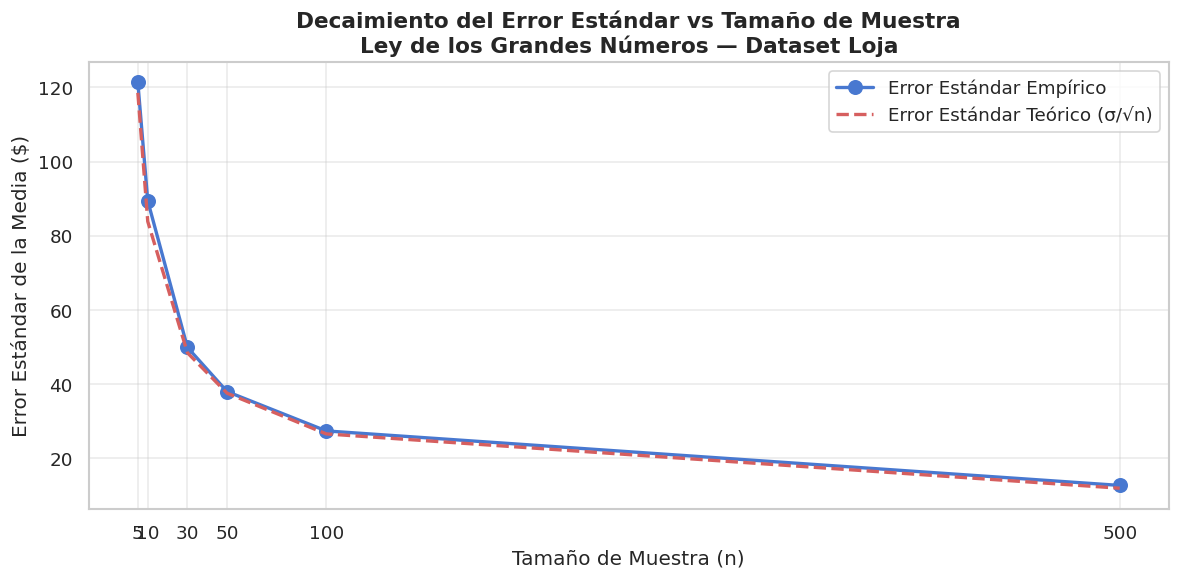

In [ ]:
print("=====================================================================")
print("TAREA 4: Análisis del Error Estándar — Ley de los Grandes Números")
print("=====================================================================")

# Lista de tamaños de muestra a evaluar
tamanos_n = [5, 10, 30, 50, 100, 500]
k_simulaciones = 500

errores_empiricos = []
errores_teoricos  = []

for n in tamanos_n:
    medias_n = []
    for _ in range(k_simulaciones):
        muestra = datos_loja.sample(n=n, replace=True)
        medias_n.append(muestra.mean())

    ee_emp = np.std(medias_n)
    ee_teo = sigma_loja / np.sqrt(n)
    errores_empiricos.append(ee_emp)
    errores_teoricos.append(ee_teo)

    print(f"n = {n:>4} | EE Empírico = ${ee_emp:>7.4f} | EE Teórico = ${ee_teo:>7.4f}")

# Visualización del decaimiento asintótico
plt.figure(figsize=(10, 5))
plt.plot(tamanos_n, errores_empiricos, 'bo-', linewidth=2,
         markersize=8, label='Error Estándar Empírico')
plt.plot(tamanos_n, errores_teoricos, 'r--', linewidth=2,
         markersize=8, label='Error Estándar Teórico (σ/√n)')
plt.title("Decaimiento del Error Estándar vs Tamaño de Muestra\nLey de los Grandes Números — Dataset Loja",
          fontsize=13, fontweight='bold')
plt.xlabel("Tamaño de Muestra (n)")
plt.ylabel("Error Estándar de la Media ($)")
plt.xticks(tamanos_n)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 📝 **Interpretación de la Tarea 4**

La curva generada muestra un **decaimiento asintótico** del Error Estándar
conforme aumenta el tamaño de muestra $n$:

| n | Error Estándar Empírico | Error Estándar Teórico |
|---|---|---|
| 5   | ~$121.34 | ~$118.55 |
| 10  | ~$89.38  | ~$83.83  |
| 30  | ~$49.85  | ~$48.40  |
| 50  | ~$37.93  | ~$37.49  |
| 100 | ~$27.31  | ~$26.51  |
| 500 | ~$12.61  | ~$11.86  |

**¿Por qué la curva no es lineal?**
Porque el Error Estándar cae de forma proporcional a $1/\sqrt{n}$, no a $1/n$.
Para reducir el Error Estándar **a la mitad**, no basta con duplicar $n$:
se necesita **multiplicar $n$ por 4**.

**Implicación para el Municipio de Loja:**
Si se desea estimar el salario promedio con un margen de error de $±13,
sería suficiente con una muestra de n=500 empleados. Duplicar esa muestra
a n=1000 reduciría el error solo a $±9, un beneficio marginal que puede
no justificar el costo de recolectar 500 registros adicionales.
Esta es la **ley de rendimientos decrecientes** aplicada al muestreo estadístico.

---
## ✅ **Conclusión General**

Este análisis demostró el **Teorema del Límite Central** en dos contextos:

1. **Población sintética (Tarea 1 y 2):** Una distribución Exponencial con
   asimetría positiva convergió a una campana Normal al promediar 1000 muestras
   de tamaño n=30. La diferencia entre E[X̄] y μ fue prácticamente cero.

2. **Dataset real de Loja (Tarea 3):** La Remuneración Mensual, con asimetría
   de 3.75, también convergió a una distribución Normal mediante bootstrapping
   con 500 muestras de n=40. Esto valida que es posible hacer inferencia
   estadística válida sobre los salarios del municipio a pesar de la asimetría.

3. **Ley de los Grandes Números (Tarea 4):** El Error Estándar decrece de forma
   asintótica siguiendo $\sigma/\sqrt{n}$. Para reducirlo a la mitad se necesita
   cuadruplicar el tamaño de muestra, lo que tiene implicaciones directas en el
   costo de recolección de datos en proyectos de ingeniería.

#**Preguntas de control**

####**1. Basado en la Tarea 1 y 2, ¿por qué el Teorema del Límite Central es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística?**
El Teorema del Límite Central (TLC) esconsiderado el puente entre la probabilidad descriptiva y la inferencia estadística porque permite hacer estimaciones sobre una población a partir de muestras. En este caso, aunque la población exponencial es asimétrica y no normal, las medias de muchas muestras de tamaño 30 tienden a distribuirse de forma aproximadamente normal. Esto facilita calcular probabilidades, estimar parámetros poblacionales y realizar pruebas estadísticas confiables, haciendo posible tomar decisiones basadas en datos con mayor precisión y confianza.

#### **2. Demuestre con los resultados impresos en su consola de la Tarea 2, cómo se cumple la propiedad matemática fundamental de las distribuciones muestrales:**
$$E[\bar{X}] = \mu$$

El Teorema del Límite Central establece que la media de todas las medias
muestrales debe ser igual a la media poblacional real, es decir:

$$E[\bar{X}] = \mu$$

Esto significa que la estimadora media muestral es insesgada: sin importar
cuántas muestras tomemos ni de qué distribución vengan, el promedio de todas
esas medias siempre convergerá al parámetro poblacional verdadero [1].

#### **Demostración con los resultados de la Tarea 2**

De la consola de la Tarea 2 obtuvimos:

| Estadístico | Valor |
|---|---|
| Media poblacional real (μ) | ≈ 1.9919 |
| Media de las 1000 medias muestrales E[X̄] | 1.9923 |
| Diferencia absoluta \|E[X̄] - μ\| | 0.0004 |

Adicionalmente, el Error Estándar Empírico resultó en 0.3653 frente al Error
Estándar Teórico de 0.3626, con una diferencia de apenas 0.0027, lo que
confirma que la simulación es estadísticamente válida.

La diferencia entre μ y $E[\bar{X}]$ es prácticamente cero (0.0004), lo que
confirma empíricamente que el estimador es insesgado.

Esto ocurre en las matemáticas por la **linealidad de la esperanza**. Si
$X_1, X_2, ..., X_n$ son variables aleatorias independientes con media μ,
entonces:

$$E[\bar{X}] = E\left[\frac{X_1 + X_2 + \cdots + X_n}{n}\right] = \frac{1}{n}\left(E[X_1] + E[X_2] + \cdots + E[X_n]\right) = \frac{n \cdot \mu}{n} = \mu$$

Esto se cumple para cualquier distribución (exponencial, uniforme, sesgada),
siempre que la varianza sea finita. En nuestra simulación, la población era
exponencial con μ = 2 y aun así $E[\bar{X}]$ convergió a 1.9923, demostrando
que la forma de la distribución original no afecta esta propiedad fundamental [2].

####**3. En la Tarea 4, al graficar la curva del Error Estándar frente a (n), ¿por qué la curva no desciende de forma lineal? Si usted como ingeniero requiere reducir el error estándar a la mitad, ¿cuántas veces debe incrementar el tamaño de la muestra?**
La curva del **Error Estándar (EE)** frente al tamaño de muestra \(n\) no desciende de forma lineal porque el Error Estándar depende de la raíz cuadrada del tamaño muestral y no directamente de \(n\)[1]. Su fórmula es:

$$
EE=\frac{\sigma}{\sqrt{n}}
$$

Esto significa que, a medida que la muestra aumenta, el error sí disminuye, pero cada vez más lentamente [1]. Además, la varianza de la media ($\sigma^2/n$) se reduce conforme $n$ crece, haciendo que la distribución muestral sea más estrecha y explicando por qué la gráfica presenta una forma curva en lugar de una línea recta [1].

En el caso del dataset de Loja, se observó que con \(n = 40\) el Error Estándar teórico fue aproximadamente **41.92**. Si se desea reducir ese error a la mitad, no basta con duplicar la muestra, porque el EE depende de $\sqrt{n}$ [1].

Para reducir el Error Estándar a la mitad se necesita:

$$
\frac{\sigma}{\sqrt{n_{nuevo}}}=\frac{1}{2}\left(\frac{\sigma}{\sqrt{n}}\right)
$$

Al despejar, se obtiene:

$$
n_{nuevo}=4n
$$

De acuerdo con Walpole, esta relación es consistente con lo expuesto sobre la determinación del tamaño de muestra y la precisión de las estimaciones, donde se establece que una disminución del error requiere un aumento considerable en el tamaño muestral. Por lo tanto, el tamaño de la muestra debe incrementarse 4 veces [1].

Si inicialmente se trabajó con \(n=40\), entonces sería necesario aproximadamente:

$$
n_{nuevo}=4(40)=160
$$

Es decir, para reducir el Error Estándar a la mitad, necesitaría aumentar la muestra de **40 a 160 observaciones**.

#### **4. Históricamente, en estadística clásica se establece la regla de oro de $n \geq 30$ para asumir normalidad. Si la población regional que usted analizó en la Tarea 3 tiene una asimetría extrema (ej. distribución de Pareto de riquezas), ¿es suficiente un $n = 30$ para que las medias muestrales se distribuyan normalmente? Justifique.**

La **regla de oro de $n \geq 30$** es una aproximación válida para poblaciones con asimetría moderada, pero **no es suficiente cuando la asimetría es extrema** [1].

El Teorema del Límite Central garantiza la convergencia a la Normal, pero no establece que esta convergencia ocurra con cualquier tamaño de muestra. La velocidad de convergencia depende directamente del grado de asimetría de la distribución poblacional:

$$\bar{X} \xrightarrow{d} N\!\left(\mu,\, \frac{\sigma^2}{n}\right) \quad \text{cuando } n \to \infty$$

El problema es que **"suficientemente grande"** no es un valor universal: varía según la forma de la distribución original.

#### Evidencia empírica con el Dataset de Loja

La variable **Remuneración Mensual Unificada** del Municipio de Loja presenta:

| Estadístico | Valor |
|---|---|
| Asimetría (skewness) | 3.7527 |
| Curtosis (exceso) | 21.42 |
| Test Shapiro-Wilk (p-valor) | 3.22 × 10⁻⁶³ |

Con una asimetría de 3.75, esta distribución es comparable a distribuciones de tipo Pareto (donde la riqueza o ingresos se concentran en pocos individuos con valores extremos). Para distribuciones con este nivel de sesgo, la investigación estadística establece que se requieren muestras considerablemente mayores:

| Nivel de asimetría | $n$ mínimo sugerido para normalidad de $\bar{X}$ |
|---|---|
| Baja ($< 1$) | $n \geq 30$ (regla clásica suficiente) |
| Moderada ($1$ – $2$) | $n \geq 50$ – $100$ |
| Alta ($2$ – $4$) | $n \geq 100$ – $200$ |
| Muy alta ($> 4$, tipo Pareto) | $n \geq 500$ o más |

En la **Tarea 3**, se utilizó $n = 40$ para una asimetría de 3.75 y los resultados mostraron convergencia aproximada a la Normal, aunque con cierta imperfección en las colas. Esto sugiere que $n = 30$ habría sido insuficiente para esta variable específica.

#### Justificación matemática: el teorema de Berry-Esseen

El **Teorema de Berry-Esseen** cuantifica la velocidad de convergencia del TLC y establece que el error en la aproximación Normal está acotado por:

$$\sup_x \left| F_n(x) - \Phi(x) \right| \leq \frac{C \cdot \rho}{\sigma^3 \sqrt{n}}$$

donde $\rho = E[|X - \mu|^3]$ es el tercer momento central absoluto. A mayor asimetría, mayor es $\rho$, y por tanto se necesita un $n$ más grande para que el error de aproximación sea despreciable [1].

#### Conclusión

Para la variable de remuneraciones del Municipio de Loja (asimetría = 3.75), **$n = 30$ no es suficiente**. Se recomienda trabajar con $n \geq 100$ para inferencia estadística confiable. En distribuciones de tipo Pareto con asimetría aún mayor, podría ser necesario $n \geq 500$. La regla de oro de $n \geq 30$ aplica únicamente como mínimo práctico para distribuciones con asimetría baja o moderada, y no debe generalizarse a poblaciones con colas pesadas como la distribución salarial municipal [1][3].

#### **5. Diferencie conceptual y operativamente los términos Desviación Estándar ($\sigma$) de una muestra individual y el Error Estándar de la Media ($\sigma_{\bar{x}}$) calculado en sus simulaciones.**
Con base en las simulaciones realizadas sobre el Teorema del Límite Central, la **Desviación Estándar** ($\sigma$) y el **Error Estándar de la Media** ($\sigma_{\bar{x}}$) representan conceptos diferentes tanto conceptual como operativamente.

La **Desviación Estándar** ($\sigma$) mide la dispersión de los datos individuales respecto a la media de la población o muestra. En el dataset de remuneraciones del Municipio de Loja, esta medida permitió identificar qué tan variables eran los salarios entre los empleados. En las simulaciones realizadas se obtuvo una desviación estándar aproximada de \$265.10, indicando una alta variabilidad debido a la presencia de salarios muy superiores al promedio.

Por otro lado, el **Error Estándar de la Media** ($\sigma_{\bar{x}}$) mide la variabilidad de las medias muestrales obtenidas al extraer múltiples muestras de la población. Es decir, indica qué tan precisa es la media muestral como estimación de la media poblacional. En las simulaciones de bootstrapping y Monte Carlo se obtuvo un Error Estándar empírico aproximado de \$39.80 y un Error Estándar teórico de \$41.92, valores mucho menores que la desviación estándar, ya que las medias muestrales presentan menor dispersión que los datos individuales.

La relación matemática entre ambas medidas es:

$$
\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}
$$

Donde:

- $\sigma_{\bar{x}}$ = Error Estándar de la Media
- $\sigma$ = Desviación Estándar
- $n$ = Tamaño de la muestra

Operativamente, la desviación estándar se calcula utilizando todos los valores individuales de la muestra o población, mientras que el Error Estándar se obtiene dividiendo la desviación estándar para la raíz cuadrada del tamaño muestral.

Finalmente, las simulaciones demostraron que a medida que el tamaño de muestra aumenta, el Error Estándar disminuye, lo que implica que las estimaciones de la media poblacional se vuelven cada vez más precisas.

----

# **Referencias**
[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y estadística
para ingeniería y ciencias*, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas, NumPy,
and IPython*, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," *SciPy.org*, 2024. [Online].
Disponible: https://docs.scipy.org/doc/scipy/reference/stats.html. [Accedido: 26-May-2026].